In [1]:
import pandas as pd
import numpy as np
from surrogate import SurrogateAutoMLModel
from surrogate import SurrogateTabPFN
import sklearn
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('water_tank_exps.csv')

## train surrogate model on CV data

In [2]:
def get_cv_data(df, fold):
    
    df_train = []
    
    df_test = []
    
    for i in range(fold):
        
        df1 = df.copy()
        
        i1 = int(len(df1) / fold * i)
        i2 = int(len(df1) / fold * (i+1))
        
        index = df1.iloc[i1:i2]
        
        train = df1[~df1.index.isin(index.index)]
        
        df_train.append(train)
        
        df_test.append(index)
        
        assert len(train) + len(index) == len(df1)
        
    return df_train, df_test

def get_pred_res(df_train, df_test, Xvars=['action_mode', 'tg_threshold', 'water_tank_size'], yvar='urbac'):
    estimator_list = ['rf', 'xgboost', 'lgbm']
    amodel = SurrogateAutoMLModel(time_budget=60, verbose=1, n_jobs=-1)
    tmodel = SurrogateTabPFN(time_budget=None)
    
    X_train, y_train, X_test, y_test = df_train[Xvars], df_train[yvar], df_test[Xvars], df_test[yvar]
    
    amodel.train(X_train, y_train)
    tmodel.train(X_train, y_train)
    
    amodel_pred = amodel.predict(X_test)
    tmodel_pred = tmodel.predict(X_test)
    
    res = {}
    
    a_mae = sklearn.metrics.mean_absolute_error(y_test, amodel_pred)
    t_mae = sklearn.metrics.mean_absolute_error(y_test, tmodel_pred)
    
    a_rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_test, amodel_pred))
    t_rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_test, tmodel_pred))
    
    a_r2 = sklearn.metrics.r2_score(y_test, amodel_pred)
    t_r2 = sklearn.metrics.r2_score(y_test, tmodel_pred)
    
    a_mape = sklearn.metrics.mean_absolute_percentage_error(y_test, amodel_pred)
    t_mape = sklearn.metrics.mean_absolute_percentage_error(y_test, tmodel_pred)
    
    res['AutoML'] = {'MAE': a_mae, 'RMSE': a_rmse, 'R2': a_r2, 'MAPE': a_mape}
    res['TabPFN'] = {'MAE': t_mae, 'RMSE': t_rmse, 'R2': t_r2, 'MAPE': t_mape}
    
    return res


In [3]:
def get_cv_results(df, fold):
    
    df_train, df_test = get_cv_data(df, fold)
    
    res = pd.DataFrame()
    
    for i in range(fold):
        
        train = df_train[i]
        test = df_test[i]
        
        print('Fold:', i)
        
        print('Train:', len(train))
        print('Test:', len(test))
        
        res1 = get_pred_res(train, test)
        
        res1_df1 = pd.DataFrame({
            'flod': [i], 'model': ['AutoML'], 'MAE': [res1['AutoML']['MAE']], 'RMSE': [res1['AutoML']['RMSE']], 'R2': [res1['AutoML']['R2']], 'MAPE': [res1['AutoML']['MAPE']]
        })
        
        res1_df2 = pd.DataFrame({
            'flod': [i], 'model': ['TabPFN'], 'MAE': [res1['TabPFN']['MAE']], 'RMSE': [res1['TabPFN']['RMSE']], 'R2': [res1['TabPFN']['R2']], 'MAPE': [res1['TabPFN']['MAPE']]
        })
        
        res = pd.concat([res, res1_df1, res1_df2])
        
    return res

In [4]:
compare_res = get_cv_results(df, 10)
compare_res.to_csv('surrogate_compare_res.csv', index=False)

Fold: 0
Train: 360
Test: 40
Fold: 1
Train: 360
Test: 40
Fold: 2
Train: 360
Test: 40
Fold: 3
Train: 360
Test: 40
Fold: 4
Train: 360
Test: 40
Fold: 5
Train: 360
Test: 40
Fold: 6
Train: 360
Test: 40
Fold: 7
Train: 360
Test: 40
Fold: 8
Train: 360
Test: 40
Fold: 9
Train: 360
Test: 40


<Axes: xlabel='variable', ylabel='value'>

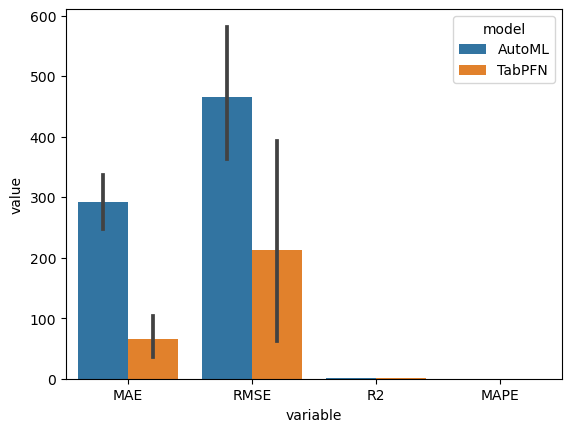

In [5]:
import seaborn as sns
df_plot = pd.read_csv('surrogate_compare_res.csv').melt(id_vars=['flod', 'model'], value_vars=['MAE', 'RMSE', 'R2', 'MAPE'])
sns.barplot(x='variable', y='value', hue='model', data=df_plot)

## train on the whole dataset

In [6]:
amodel = SurrogateAutoMLModel(time_budget=60, verbose=1, n_jobs=-1)
tmodel = SurrogateTabPFN(time_budget=None)
amodel.train(df[['action_mode', 'tg_threshold', 'water_tank_size']], df['urbac'])
tmodel.train(df[['action_mode', 'tg_threshold', 'water_tank_size']], df['urbac'])

amodel.save_model('amodel.pkl')
tmodel.save_model('tmodel.pkl')